In [ ]:
import os
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from datasets import load_dataset
from peft import LoraConfig, prepare_model_for_kbit_training

# --- CONFIGURATION ---
PROJECT_DIR = r"D:\Md. Al Baki Akon\A-RICD"
MODEL_NAME = "meta-llama/Llama-2-7b-hf" 
DATA_PATH = os.path.join(PROJECT_DIR, "data", "processed_training", "cleaned", "sota_train_bio.jsonl")
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "models", "llama2-bio-checkpoints")
ADAPTER_OUTPUT = os.path.join(PROJECT_DIR, "models", "amateur_bio_adapter")

# 4-bit Quantization Config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Hardware: {DEVICE}")

Hardware: cuda


In [19]:
# Clear VRAM from any previous failed runs
if "trainer" in locals(): del trainer
if "model" in locals(): del model
torch.cuda.empty_cache()

# Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# Load Base Model
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

# Prepare for LoRA
model = prepare_model_for_kbit_training(model)
print("Fresh base model loaded and ready.")

Loading weights: 100%|██████████| 291/291 [00:04<00:00, 64.02it/s, Materializing param=model.norm.weight]                               


Fresh base model loaded and ready.


In [20]:
# Load Dataset
dataset = load_dataset("json", data_files=DATA_PATH, split="train")

# Define Amateur LoRA Configuration
peft_config = LoraConfig(
    r=64, 
    lora_alpha=128, 
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj", "gate_proj", "up_proj", "down_proj"], 
    lora_dropout=0.05, 
    bias="none", 
    task_type="CAUSAL_LM"
)

print(f"Dataset Loaded: {len(dataset)} samples. LoRA Config initialized.")

Dataset Loaded: 3392 samples. LoRA Config initialized.


In [21]:
from trl import SFTTrainer, SFTConfig

# 1. Version-Corrected Config
sft_config = SFTConfig(
    output_dir=CHECKPOINT_DIR,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=1e-4,
    num_train_epochs=3,
    logging_steps=10,
    bf16=True,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,
    gradient_checkpointing=True,
    report_to="none",
    dataset_text_field="text",
    max_length=512,
    packing=False
)

# 2. Initialize Trainer
trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    peft_config=peft_config,
    args=sft_config
)

# 3. Resume Logic
last_checkpoint = None
if os.path.exists(CHECKPOINT_DIR):
    checkpoints = [d for d in os.listdir(CHECKPOINT_DIR) if "checkpoint" in d]
    if checkpoints:
        last_checkpoint = True
        print("Resuming training from checkpoint...")

# 4. Start
trainer.train(resume_from_checkpoint=last_checkpoint)

# 5. Save
trainer.model.save_pretrained(ADAPTER_OUTPUT)
tokenizer.save_pretrained(ADAPTER_OUTPUT)
print(f"Amateur Bio-Adapter saved to: {ADAPTER_OUTPUT}")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': None}.


Step,Training Loss
10,1.379193
20,1.064480
30,1.019685
40,1.022503
50,1.013073
60,1.003047
70,0.987855
80,0.986586
90,0.996080
100,0.968647


Amateur Bio-Adapter saved to: D:\Md. Al Baki Akon\A-RICD\training_scripts\models\amateur_bio_adapter


✅ Publication-grade plots saved to: D:\Md. Al Baki Akon\A-RICD\Llama_bio_training_loss_900dpi.png


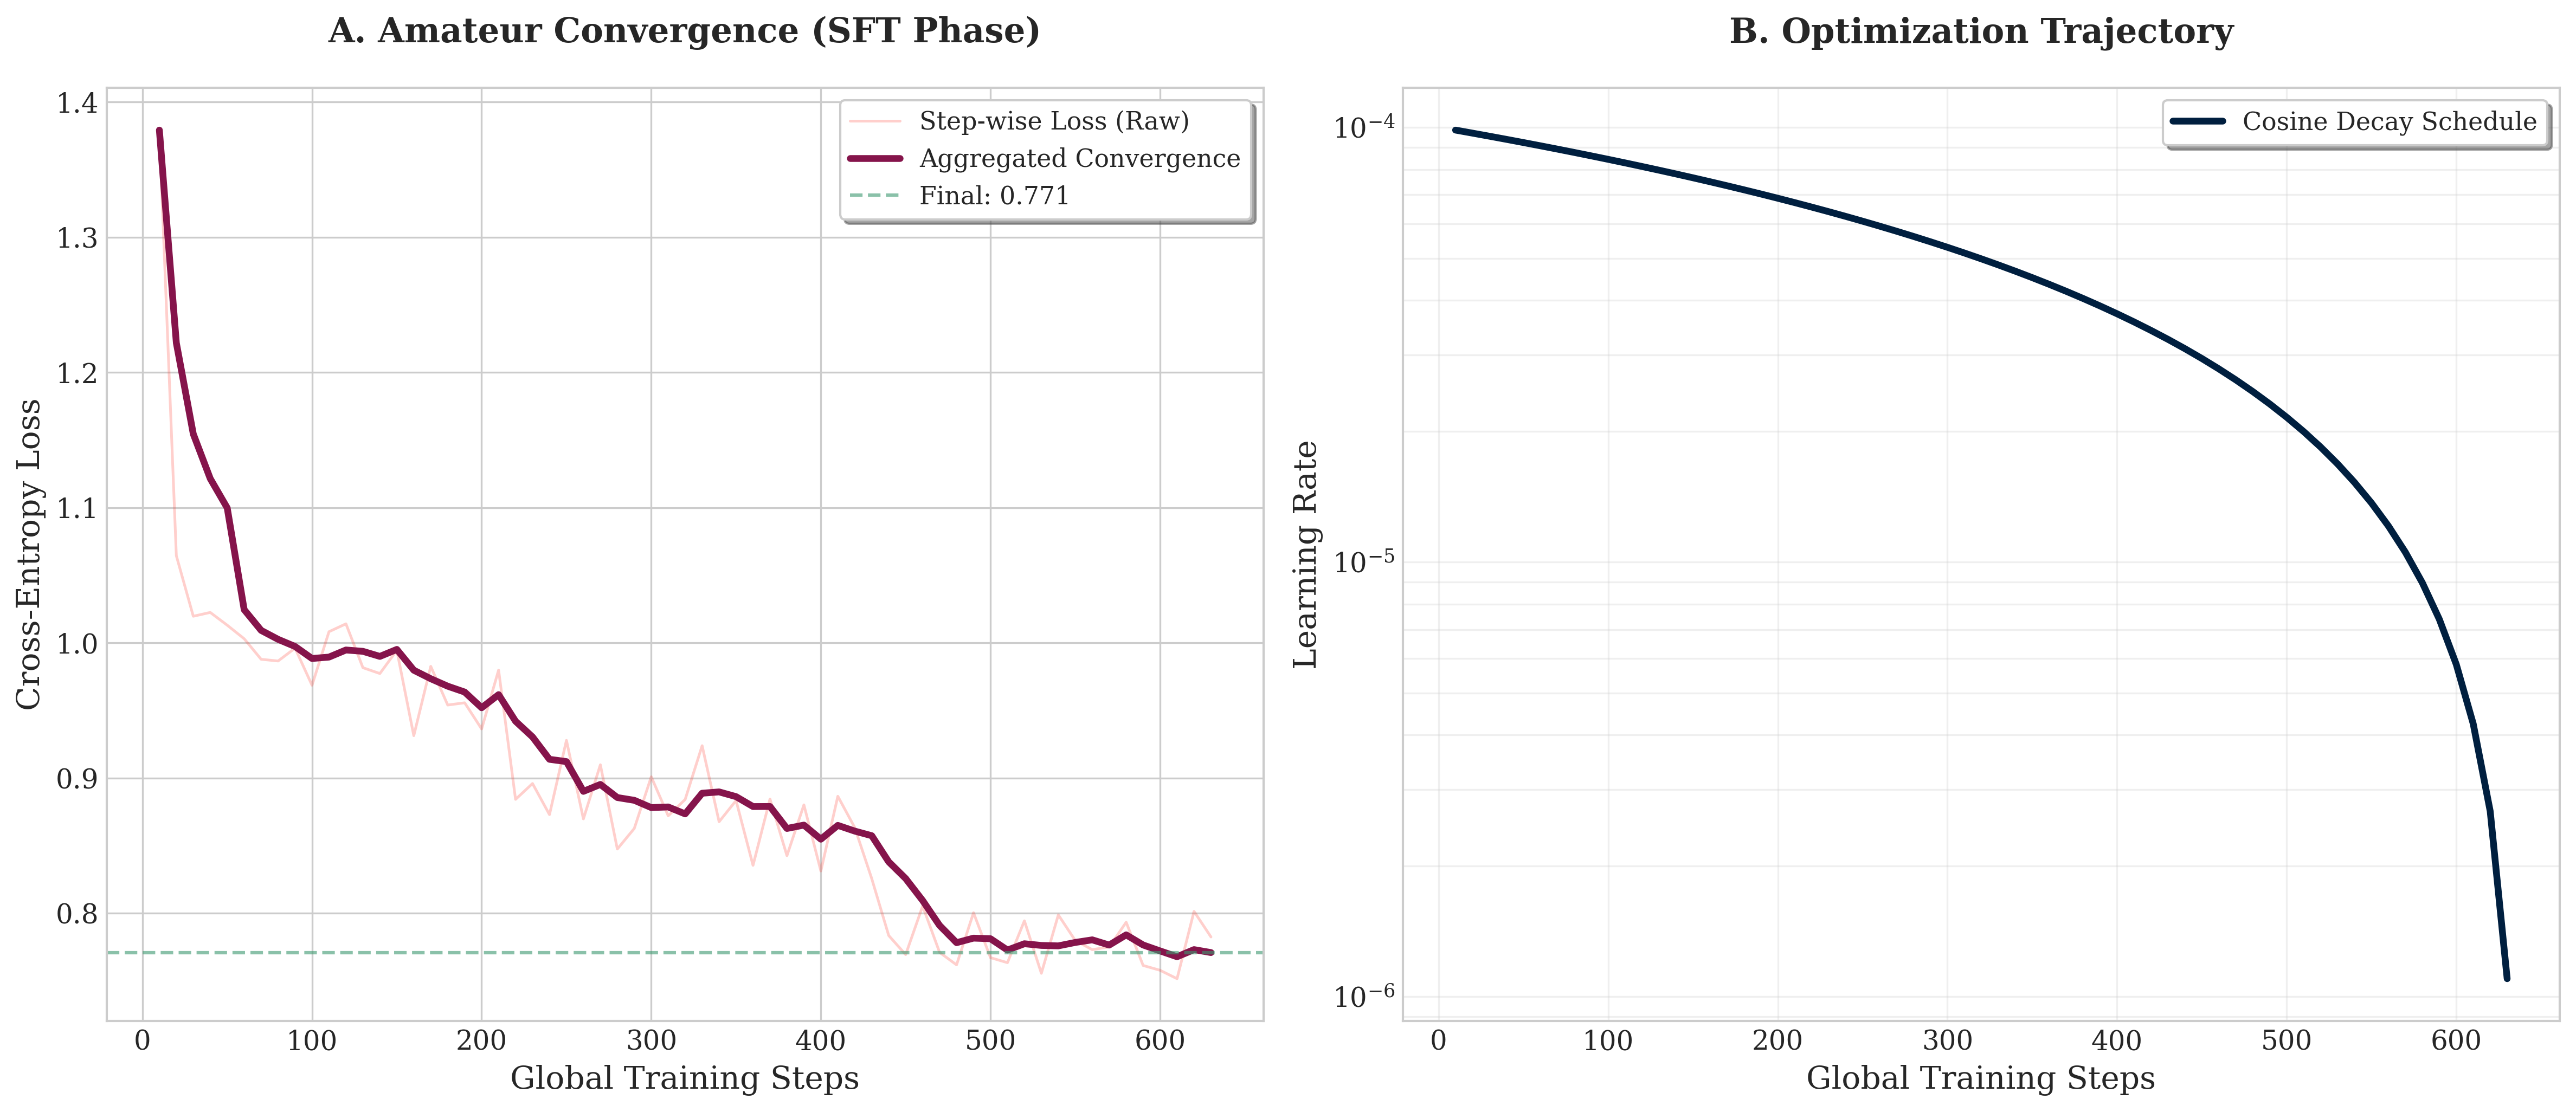

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# 1. Extract Training Logs from the 'trainer' object
if 'trainer' in locals() and hasattr(trainer, 'state'):
    history = trainer.state.log_history
    df = pd.DataFrame(history)
    # Filter for rows that actually contain training loss
    train_loss_df = df[df['loss'].notna()].copy()

    # 2. Advanced Publication Styling
    plt.style.use('seaborn-v0_8-whitegrid') 
    plt.rcParams.update({
        'font.size': 12,
        'font.family': 'serif',
        'axes.labelsize': 14,
        'axes.titlesize': 15,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 11,
        'figure.titlesize': 18,
        'figure.dpi': 300  # High-quality display in notebook
    })

    # 3. Create Multi-Panel Figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # --- Plot A: Training Loss (High Contrast Crimson/Maroon) ---
    # We use a rolling average to show the trend clearly through the noise
    window_size = 5 if len(train_loss_df) > 10 else 1
    train_loss_df['smoothed_loss'] = train_loss_df['loss'].rolling(window=window_size, min_periods=1).mean()

    # Raw Loss: Vibrant Red (Semi-transparent)
    ax1.plot(train_loss_df['step'], train_loss_df['loss'], 
             color='#FF4136', alpha=0.25, linewidth=1.2, label='Step-wise Loss (Raw)')
    
    # Smoothed Trend: Deep Maroon (Solid & Thick)
    ax1.plot(train_loss_df['step'], train_loss_df['smoothed_loss'], 
             color='#85144B', linewidth=3, label='Aggregated Convergence')
    
    # Add a horizontal goal-line (Standard for SOTA papers)
    final_loss = train_loss_df['smoothed_loss'].iloc[-1]
    ax1.axhline(y=final_loss, color='#3D9970', linestyle='--', alpha=0.6, label=f'Final: {final_loss:.3f}')

    ax1.set_title('A. Amateur Convergence (SFT Phase)', fontweight='bold', pad=20)
    ax1.set_xlabel('Global Training Steps')
    ax1.set_ylabel('Cross-Entropy Loss')
    ax1.legend(frameon=True, loc='upper right', shadow=True)

    # --- Plot B: Learning Rate (Deep Oxford Blue) ---
    # Using a deep navy to contrast the red of Plot A
    ax2.plot(train_loss_df['step'], train_loss_df['learning_rate'], 
             color='#001F3F', linewidth=3, label='Cosine Decay Schedule')
    
    ax2.set_title('B. Optimization Trajectory', fontweight='bold', pad=20)
    ax2.set_xlabel('Global Training Steps')
    ax2.set_ylabel('Learning Rate')
    ax2.set_yscale('log') # Log scale is standard for showing LR decay accurately
    ax2.grid(True, which="both", ls="-", alpha=0.3)
    ax2.legend(frameon=True, loc='upper right', shadow=True)

    plt.tight_layout()

    # 4. Save for Research Paper (Extreme Resolution)
    # Using 900 DPI ensures zero pixelation in PDF publications
    output_filename = "Llama_bio_training_loss_900dpi.png"
    loss_plot_path = os.path.join(PROJECT_DIR, output_filename)
    plt.savefig(loss_plot_path, dpi=900, bbox_inches='tight')

    print(f"✅ Publication-grade plots saved to: {loss_plot_path}")
    plt.show()

else:
    print("❌ Error: Trainer object or log history not found. Please ensure training has started.")